# GROMACS Protein-DNA Molecular Dynamics Simulation Protocol

Molecular Dynamics protocol for McMaster iGEM's REACT 2025 project.

## Requirements

### Non-Conda Environment

#### System Requirements
- **GROMACS**: Version 2020 or later (compiled with MPI support for parallel simulations)
- **Python**: 3.7 or later
- **Operating System**: Linux (recommended for HPC clusters)

### Conda Environment
Use our existing YAML file to create a conda environment:
```bash
conda env create -f environment.yml
```

Or install a new environment:
- GROMACS Conda installation (https://anaconda.org/conda-forge/gromacs)

### Molecular Dynamics
**Python Dependencies**
- We use the `gmx_MMPBSA` package to perform interaction entropy analysis, installation is already included in the YAML file and can be found here: https://valdes-tresanco-ms.github.io/gmx_MMPBSA/1.6.4/installation/

**Force Field**
- We use the CHARMM36 forcefield. This can be downloaded from the Mackerell Lab (https://mackerell.umaryland.edu/charmm_ff.shtml#gromacs)

**MDP Files**
- All MDP files we used are adapted from: http://www.mdtutorials.com/gmx/complex/04_ions.html

## 1. PDB Pre-processing

We have to replace residue and label names in our PDB containing the protein-DNA complex as CHARMM36 reference names in (.rtp/.rtf files) are slightly different.

What it does (by default):
- DNA/RNA phosphates: OP1→O1P, OP2→O2P, (and OP3→O3P if present)
- Thymine methyl (DT): C7→C5M; H71/H72/H73→H5M1/H5M2/H5M3
- Sugar prime/star:  * → '  (e.g., O3*→O3', H5*1→H5'1, etc.)
- Sugar geminal Hs: H2'1→H2', H2'2→H2''  and  H5'1→H5', H5'2→H5''
- Keeps strict PDB column widths (atom name right-justified to 4 chars)

Optional:
- Auto-assign HIS → HSD/HSE/HSP with --auto-his
    - If HD1 only → HSD (δ-tautomer)
    - If HE2 only → HSE (ε-tautomer)
    - If both HD1 and HE2 → HSP (diprotonated)
    - If neither → leave as HIS (or --auto-his-default to set fallback)

In [ ]:
python c36_pdb_format.py input.pdb -o output.pdb --auto-his

## 2. Generate Topology

1. We use `pdb2gmx` to generate the topology. Here, we manually select NH3+ and COO- terminals for the protein, and 5PHO and 3TER termianls for the DNA sequence. 

In [ ]:
gmx pdb2gmx -f data/110nt_CXCL9_docked_fixed.pdb -o complex.gro -water tip3p -ter -ignh

<details>
  <summary>Sample Output</summary>

```text
Processing chain 1 'A' (980 atoms, 125 residues)
Analysing hydrogen-bonding network for automated assignment of histidine protonation. 201 donors and 171 acceptors were found.
There are 250 hydrogen bonds
Will use HISE for residue 42
Will use HISE for residue 105

Identified residue MET1 as a starting terminus.

Identified residue THR125 as a ending terminus.
9 out of 9 lines of specbond.dat converted successfully
Special Atom Distance matrix:
                    MET1   CYS31   CYS33   HIS42   CYS58   CYS74
                     SD7   SG230   SG242  NE2306   SG431   SG552
   CYS31   SG230   4.785
   CYS33   SG242   5.553   0.776
   HIS42  NE2306   7.424   2.799   2.108
   CYS58   SG431   4.922   0.285   0.735   2.728
   CYS74   SG552   5.740   0.992   0.257   1.926   0.984
  HIS105  NE2806   8.689   4.405   3.907   3.671   4.157   3.922
Select start terminus type for MET-1
 0: MET1
 1: NH3+
 2: NH2
 3: HYD1
 4: 5TER
 5: 5MET
 6: 5PHO
 7: 5POM
 8: None
1
Start terminus MET-1: NH3+
Select end terminus type for THR-125
 0: COO-
 1: COOH
 2: CT2
 3: CT1
 4: HYD2
 5: MET2
 6: 3TER
 7: None
0
End terminus THR-125: COO-
Opening force field file ./charmm36-jul2022.ff/aminoacids.arn

Checking for duplicate atoms....

Generating any missing hydrogen atoms and/or adding termini.

Now there are 125 residues with 2077 atoms
Chain time...

Making bonds...

Number of bonds was 2086, now 2086

Generating angles, dihedrals and pairs...
Before cleaning: 5549 pairs
Before cleaning: 5584 dihedrals

Making cmap torsions...

There are  123 cmap torsion pairs

There are 5584 dihedrals,  343 impropers, 3831 angles
          5540 pairs,     2086 bonds and     0 virtual sites

Total mass 14041.073 a.m.u.

Total charge 22.000 e

Writing topology

Processing chain 2 'B' (2277 atoms, 110 residues)

Identified residue DC1 as a starting terminus.

Identified residue DG110 as a ending terminus.
9 out of 9 lines of specbond.dat converted successfully
Select start terminus type for DC-1
 0: NH3+
 1: NH2
 2: HYD1
 3: MET1
 4: 5TER
 5: 5MET
 6: 5PHO
 7: 5POM
 8: None
6
Start terminus DC-1: 5PHO
Select end terminus type for DG-110
 0: COO-
 1: COOH
 2: CT2
 3: CT1
 4: HYD2
 5: MET2
 6: 3TER
 7: None
6
End terminus DG-110: 3TER
```

</details>

## 3. Solvate and Ionize

1. We use a dodecahedron shaped box and solvate with water

In [ ]:
gmx editconf -f complex.gro -o newbox.gro -bt dodecahedron -d 1.0

gmx solvate -cp newbox.gro -cs spc216.gro -p topol.top -o solv.gro

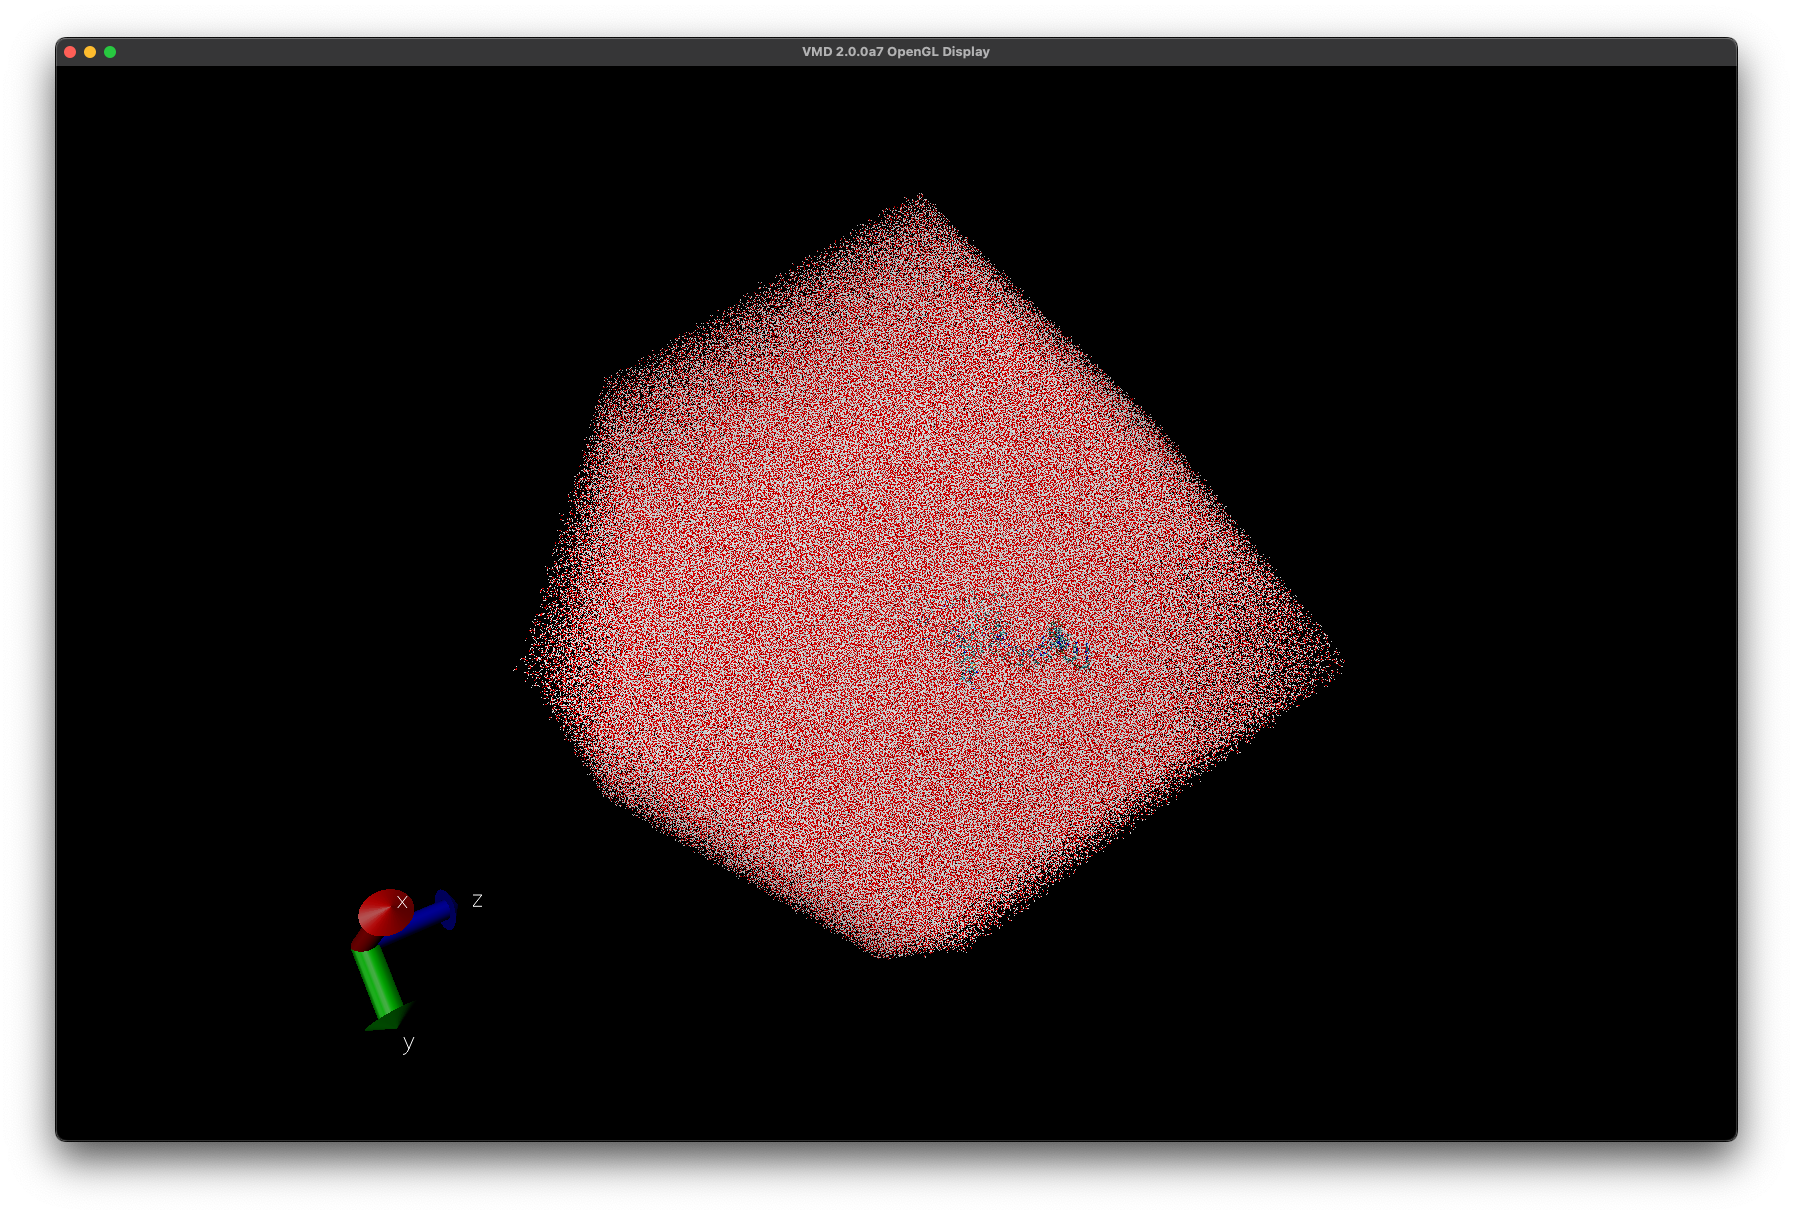

2. Then we add ions to our system to neutralize charge (negative charge for our complexes). Select Group 14 (SOL) for this step. The .mdp file can be found in `src/mdp_files/ions.mdp`

In [ ]:
gmx grompp -f ions.mdp -c solv.gro -p topol.top -o ions.tpr

gmx genion -s ions.tpr -o solv_ions.gro -p topol.top -pname NA -nname CL -neutral

<details>
  <summary>Sample Output</summary>

```text
Command line:
  gmx genion -s ions.tpr -o solv_ions.gro -p topol.top -pname NA -nname CL -neutral

Reading file ions.tpr, VERSION 2024.4-EasyBuild_4.9.4 (single precision)
Reading file ions.tpr, VERSION 2024.4-EasyBuild_4.9.4 (single precision)
Will try to add 88 NA ions and 0 CL ions.
Select a continuous group of solvent molecules
Group     0 (         System) has 685999 elements
Group     1 (        Protein) has  2077 elements
Group     2 (      Protein-H) has   981 elements
Group     3 (        C-alpha) has   125 elements
Group     4 (       Backbone) has   375 elements
Group     5 (      MainChain) has   499 elements
Group     6 (   MainChain+Cb) has   616 elements
Group     7 (    MainChain+H) has   622 elements
Group     8 (      SideChain) has  1455 elements
Group     9 (    SideChain-H) has   482 elements
Group    10 (    Prot-Masses) has  2077 elements
Group    11 (    non-Protein) has 683922 elements
Group    12 (            DNA) has  3501 elements
Group    13 (          Water) has 680421 elements
Group    14 (            SOL) has 680421 elements
Group    15 (      non-Water) has  5578 elements
Select a group: 14
Selected 14: 'SOL'
```
</details>

## 4. Energy Minimization

- We follow the standard protocol for energy minimization, our .mdp file can be found under `src/mdp_files/em.mdp`
- EM from our experiments took a few hours on an NVIDIA L4 GPU, and is recommended to be run in a batch job. Refer to `src/scripts/`

In [ ]:
gmx grompp -f em.mdp -c solv_ions.gro -p topol.top -o em.tpr

gmx mdrun -v -deffnm em

## 5. Processing for Equilibration

**1. Protein_DNA index generation**
- Since we are using a single PDB file containing our complex, we have to create a custom protein-DNA index to define the groups that GROMACS will use during equilibration and production. 
- Here, choose the protein and DNA group `1 | 12` and save as a new index.

In [ ]:
# create protein_DNA index file
gmx make_ndx -f em.gro -o prot_dna_index.ndx

<details>
<summary>Sample command line input:</summary>

```text
Command line:
  gmx make_ndx -f em.gro -o prot_dna_index.ndx


Reading structure file
Going to read 0 old index file(s)
Analysing residue names:
There are:   125    Protein residues
There are:   110        DNA residues
There are: 226719      Water residues
There are:    88        Ion residues
Analysing Protein...
Analysing residues not classified as Protein/DNA/RNA/Water and splitting into groups...

  0 System              : 685823 atoms
  1 Protein             :  2077 atoms
  2 Protein-H           :   981 atoms
  3 C-alpha             :   125 atoms
  4 Backbone            :   375 atoms
  5 MainChain           :   499 atoms
  6 MainChain+Cb        :   616 atoms
  7 MainChain+H         :   622 atoms
  8 SideChain           :  1455 atoms
  9 SideChain-H         :   482 atoms
 10 Prot-Masses         :  2077 atoms
 11 non-Protein         : 683746 atoms
 12 DNA                 :  3501 atoms
 13 NA                  :    88 atoms
 14 Water               : 680157 atoms
 15 SOL                 : 680157 atoms
 16 non-Water           :  5666 atoms
 17 Ion                 :    88 atoms
 18 Water_and_ions      : 680245 atoms

 nr : group      '!': not  'name' nr name   'splitch' nr    Enter: list groups
 'a': atom       '&': and  'del' nr         'splitres' nr   'l': list residues
 't': atom type  '|': or   'keep' nr        'splitat' nr    'h': help
 'r': residue              'res' nr         'chain' char
 "name": group             'case': case sensitive           'q': save and quit
 'ri': residue index

> 1 | 12

Copied index group 1 'Protein'
Copied index group 12 'DNA'
Merged two groups with OR: 2077 3501 -> 5578

> name 19 Protein_DNA

> q
```

</details>

**2. DNA index generation for position restraint**
- We encountered an error where the indices for our DNA-only restraint had to match the indices of our DNA `[ molecule type ]` in GROMACS, so we subsequently generate a DNA only index for position restraints.

In [ ]:
# dump the DNA only structure
gmx trjconv -s em.tpr -f em.gro -o dna_only.gro -n prot_dna_index.ndx -dump 0

<details>
    <summary>Sample command line input:</summary>

```text
Command line:
  gmx trjconv -s em.tpr -f em.gro -o dna_only.gro -n prot_dna_index.ndx -dump 0

Note that major changes are planned in future for trjconv, to improve usability and utility.
Will write gro: Coordinate file in Gromos-87 format
Reading file em.tpr, VERSION 2024.4-EasyBuild_4.9.4 (single precision)
Reading file em.tpr, VERSION 2024.4-EasyBuild_4.9.4 (single precision)
Select group for output
Group     0 (         System) has 685823 elements
Group     1 (        Protein) has  2077 elements
Group     2 (      Protein-H) has   981 elements
Group     3 (        C-alpha) has   125 elements
Group     4 (       Backbone) has   375 elements
Group     5 (      MainChain) has   499 elements
Group     6 (   MainChain+Cb) has   616 elements
Group     7 (    MainChain+H) has   622 elements
Group     8 (      SideChain) has  1455 elements
Group     9 (    SideChain-H) has   482 elements
Group    10 (    Prot-Masses) has  2077 elements
Group    11 (    non-Protein) has 683746 elements
Group    12 (            DNA) has  3501 elements
Group    13 (             NA) has    88 elements
Group    14 (          Water) has 680157 elements
Group    15 (            SOL) has 680157 elements
Group    16 (      non-Water) has  5666 elements
Group    17 (            Ion) has    88 elements
Group    18 ( Water_and_ions) has 680245 elements
Group    19 (    Protein_DNA) has  5578 elements
Select a group: 12
Selected 12: 'DNA'
Reading frames from gro file 'Protein in water', 685823 atoms.
Reading frame       0 time    0.000   
Precision of em.gro is 0.001 (nm)
Last frame          0 time    0.000   

Dumping frame at t= 0 ps
 ->  frame      0 time    0.000      
Last written: frame      0 time    0.000
```
</details>

In [ ]:
# create the DNA index
gmx make_ndx -f dna_only.gro -o dna_index.ndx

<details>
    <summary>Sample command line input:</summary>

```text
Command line:
  gmx make_ndx -f dna_only.gro -o dna_index.ndx


Reading structure file
Going to read 0 old index file(s)
Analysing residue names:
There are:   110        DNA residues

  0 System              :  3501 atoms
  1 DNA                 :  3501 atoms

 nr : group      '!': not  'name' nr name   'splitch' nr    Enter: list groups
 'a': atom       '&': and  'del' nr         'splitres' nr   'l': list residues
 't': atom type  '|': or   'keep' nr        'splitat' nr    'h': help
 'r': residue              'res' nr         'chain' char
 "name": group             'case': case sensitive           'q': save and quit
 'ri': residue index

> 0 & ! a H* 

Copied index group 0 'System'
Found 1223 atoms with name H*
Complemented group: 2278 atoms
Merged two groups with AND: 3501 2278 -> 2278

> name 1 DNA_heavy

> q
```
</details>

**3. DNA position restraint generation**
- Use the new index we created to generate a position restraint file for the DNA group.

In [ ]:
gmx genrestr -f dna_only.gro -n dna_index.ndx -o posre_isolated_DNA_chain_B.itp -fc 1000 1000 1000

**4. Update topology file with position restraints**

Make sure that the following section is added to the `topol.top` file:


In [ ]:
; Include chain topologies
#include "topol_Protein_chain_A.itp"
#include "topol_DNA_chain_B.itp"

; Include Protein position restraint
#ifdef POSRES_PROT
#include "posre_Protein_chain_A.itp"
#endif

; Include DNA position restraint
#ifdef POSRES_DNA
#include "posre_isolated_DNA_chain_B.itp"
#endif

## 6. NVT & NPT Equilibration

The batch scripts `src/scripts/nvt.sh` and `src/scripts/npt.sh` can be used instead as this step takes several hours.  <br>
<br>

1. NVT Equilibration (select the protein DNA index file that we created previously)

In [ ]:
gmx grompp -f nvt.mdp -c em.gro -r em.gro -p topol.top -n prot_dna_index.ndx -o nvt.tpr

gmx mdrun -deffnm nvt

2. NPT Equilibration (select protein DNA index file created previously)

In [ ]:
gmx grompp -f npt.mdp -c nvt.gro -t nvt.cpt -r nvt.gro -p topol.top -n prot_dna_index.ndx -o npt.tpr

gmx mdrun -v -deffnm npt

## 7. Production MD

Recommended to use batch script `src/scripts/md.sh`. Our .mdp file has a default of 20ns for simulation length, but this can be modified as needed.

In [ ]:
# preprocess for MD run
gmx grompp -f md.mdp -c npt.gro -t npt.cpt -p topol.top -n prot_dna_index.ndx -o md_1_20ns.tpr

# run MD simulation
gmx mdrun -v -deffnm md_1_20ns

## 8. Post-processing for Analysis

**1. Remove periodic boundary artifacts and jumps.** Select `system` (Group 0) as the final output

In [ ]:
gmx trjconv -s md_1_20ns.tpr -f md_1_20ns.xtc  -o md_1_20ns_nojump.xtc -pbc nojump

<details>
    <summary>Sample command line input:</summary>

```text
Command line:
  gmx trjconv -s md_1_20ns.tpr -f md_1_20ns.xtc -o md_1_20ns_nojump.xtc -pbc nojump

Note that major changes are planned in future for trjconv, to improve usability and utility.
Will write xtc: Compressed trajectory (portable xdr format): xtc
Reading file md_1_20ns.tpr, VERSION 2025.3-conda_forge (single precision)
Reading file md_1_20ns.tpr, VERSION 2025.3-conda_forge (single precision)
Select group for output
Group     0 (         System) has 685823 elements
Group     1 (        Protein) has  2077 elements
Group     2 (      Protein-H) has   981 elements
Group     3 (        C-alpha) has   125 elements
Group     4 (       Backbone) has   375 elements
Group     5 (      MainChain) has   499 elements
Group     6 (   MainChain+Cb) has   616 elements
Group     7 (    MainChain+H) has   622 elements
Group     8 (      SideChain) has  1455 elements
Group     9 (    SideChain-H) has   482 elements
Group    10 (    Prot-Masses) has  2077 elements
Group    11 (    non-Protein) has 683746 elements
Group    12 (            DNA) has  3501 elements
Group    13 (             NA) has    88 elements
Group    14 (          Water) has 680157 elements
Group    15 (            SOL) has 680157 elements
Group    16 (      non-Water) has  5666 elements
Group    17 (            Ion) has    88 elements
Group    18 ( Water_and_ions) has 680245 elements
Select a group: 0
Selected 0: 'System'
Reading frame       0 time    0.000   
Precision of md_1_20ns.xtc is 0.001 (nm)
Using output precision of 0.001 (nm)
Last frame       2000 time 20000.000    ->  frame   1999 time 19990.000      
 ->  frame   2000 time 20000.000      
Last written: frame   2000 time 20000.000
```
</details>

**2. Center the protein-DNA complex across frames.** Select `Protein_DNA` as the input group and `system` as the output group. 

In [ ]:
gmx trjconv -s md_1_20ns.tpr -f md_1_20ns_nojump.xtc -o md_1_20ns_center.xtc -center -pbc mol -ur compact -n prot_dna_index.nd

<details>
    <summary>Sample command line input:</summary>

```text
Command line:
  gmx trjconv -s md_1_20ns.tpr -f md_1_20ns_nojump.xtc -o md_1_20ns_center.xtc -center -pbc mol -ur compact -n prot_dna_index.ndx

Note that major changes are planned in future for trjconv, to improve usability and utility.
Will write xtc: Compressed trajectory (portable xdr format): xtc
Reading file md_1_20ns.tpr, VERSION 2025.3-conda_forge (single precision)
Reading file md_1_20ns.tpr, VERSION 2025.3-conda_forge (single precision)
Select group for centering
Group     0 (         System) has 685823 elements
Group     1 (        Protein) has  2077 elements
Group     2 (      Protein-H) has   981 elements
Group     3 (        C-alpha) has   125 elements
Group     4 (       Backbone) has   375 elements
Group     5 (      MainChain) has   499 elements
Group     6 (   MainChain+Cb) has   616 elements
Group     7 (    MainChain+H) has   622 elements
Group     8 (      SideChain) has  1455 elements
Group     9 (    SideChain-H) has   482 elements
Group    10 (    Prot-Masses) has  2077 elements
Group    11 (    non-Protein) has 683746 elements
Group    12 (            DNA) has  3501 elements
Group    13 (             NA) has    88 elements
Group    14 (          Water) has 680157 elements
Group    15 (            SOL) has 680157 elements
Group    16 (      non-Water) has  5666 elements
Group    17 (            Ion) has    88 elements
Group    18 ( Water_and_ions) has 680245 elements
Group    19 (    Protein_DNA) has  5578 elements
Select a group: 19
Selected 19: 'Protein_DNA'
Select group for output
Group     0 (         System) has 685823 elements
Group     1 (        Protein) has  2077 elements
Group     2 (      Protein-H) has   981 elements
Group     3 (        C-alpha) has   125 elements
Group     4 (       Backbone) has   375 elements
Group     5 (      MainChain) has   499 elements
Group     6 (   MainChain+Cb) has   616 elements
Group     7 (    MainChain+H) has   622 elements
Group     8 (      SideChain) has  1455 elements
Group     9 (    SideChain-H) has   482 elements
Group    10 (    Prot-Masses) has  2077 elements
Group    11 (    non-Protein) has 683746 elements
Group    12 (            DNA) has  3501 elements
Group    13 (             NA) has    88 elements
Group    14 (          Water) has 680157 elements
Group    15 (            SOL) has 680157 elements
Group    16 (      non-Water) has  5666 elements
Group    17 (            Ion) has    88 elements
Group    18 ( Water_and_ions) has 680245 elements
Group    19 (    Protein_DNA) has  5578 elements
Select a group: 0
Selected 0: 'System'
Reading frame       0 time    0.000   
Precision of md_1_20ns_nojump.xtc is 0.001 (nm)
Using output precision of 0.001 (nm)
Last frame       2000 time 20000.000    ->  frame   1999 time 19990.000      
 ->  frame   2000 time 20000.000      
Last written: frame   2000 time 20000.000
```
</details>

**3. (Optional) Remove rotation and translation for the protein-DNA complex for visualization.**

In [ ]:
gmx trjconv -s md_1_20ns.tpr -f md_1_20ns_center.xtc -o md_1_20ns_fit.xtc -fit rot+trans -n prot_dna_index.ndx

<details>
    <summary>Sample command line input:</summary>

```text
Command line:
  gmx trjconv -s md_1_20ns.tpr -f md_1_20ns_center.xtc -o md_1_20ns_fit.xtc -fit rot+trans -n prot_dna_index.ndx

Note that major changes are planned in future for trjconv, to improve usability and utility.
Will write xtc: Compressed trajectory (portable xdr format): xtc
Reading file md_1_20ns.tpr, VERSION 2025.3-conda_forge (single precision)
Reading file md_1_20ns.tpr, VERSION 2025.3-conda_forge (single precision)
Select group for least squares fit
Group     0 (         System) has 685823 elements
Group     1 (        Protein) has  2077 elements
Group     2 (      Protein-H) has   981 elements
Group     3 (        C-alpha) has   125 elements
Group     4 (       Backbone) has   375 elements
Group     5 (      MainChain) has   499 elements
Group     6 (   MainChain+Cb) has   616 elements
Group     7 (    MainChain+H) has   622 elements
Group     8 (      SideChain) has  1455 elements
Group     9 (    SideChain-H) has   482 elements
Group    10 (    Prot-Masses) has  2077 elements
Group    11 (    non-Protein) has 683746 elements
Group    12 (            DNA) has  3501 elements
Group    13 (             NA) has    88 elements
Group    14 (          Water) has 680157 elements
Group    15 (            SOL) has 680157 elements
Group    16 (      non-Water) has  5666 elements
Group    17 (            Ion) has    88 elements
Group    18 ( Water_and_ions) has 680245 elements
Group    19 (    Protein_DNA) has  5578 elements
Select a group: 19
Selected 19: 'Protein_DNA'
Select group for output
Group     0 (         System) has 685823 elements
Group     1 (        Protein) has  2077 elements
Group     2 (      Protein-H) has   981 elements
Group     3 (        C-alpha) has   125 elements
Group     4 (       Backbone) has   375 elements
Group     5 (      MainChain) has   499 elements
Group     6 (   MainChain+Cb) has   616 elements
Group     7 (    MainChain+H) has   622 elements
Group     8 (      SideChain) has  1455 elements
Group     9 (    SideChain-H) has   482 elements
Group    10 (    Prot-Masses) has  2077 elements
Group    11 (    non-Protein) has 683746 elements
Group    12 (            DNA) has  3501 elements
Group    13 (             NA) has    88 elements
Group    14 (          Water) has 680157 elements
Group    15 (            SOL) has 680157 elements
Group    16 (      non-Water) has  5666 elements
Group    17 (            Ion) has    88 elements
Group    18 ( Water_and_ions) has 680245 elements
Group    19 (    Protein_DNA) has  5578 elements
Select a group: 0
Selected 0: 'System'
Reading frame       0 time    0.000   
Precision of md_1_20ns_center.xtc is 0.001 (nm)
Using output precision of 0.001 (nm)
Last frame       2000 time 20000.000    ->  frame   1999 time 19990.000      
 ->  frame   2000 time 20000.000      
Last written: frame   2000 time 20000.000
```
</details>

## 9. H-Bond Analysis

We run hbond analysis to obtain distriubtion of h-bond angles, h-bond distance, and the number of h-bond's formed over time. Select the `Protein` and `DNA` group (separate) as input for GROMACS.

In [ ]:
gmx hbond -s ../md_1_20ns.tpr -f ../md_1_20ns_fit.xtc -n ../prot_dna_index.ndx -num hbnum_20ns.xvg -dist hbdist_20ns.xvg -ang  hbang_20ns.xvg

## 10. Trajectory Analysis

Examples here show RMSD and RMSF over time. We selected the `Protein_DNA` group for analysis.

In [ ]:
gmx rms -s md_1_20ns.tpr -f md_1_20ns_fit.xtc -n prot_dna_index.ndx -o rmsd_protein.xvg -tu ns

gmx rmsf -s md_1_20ns.tpr -f md_1_20ns_fit.xtc -n prot_dna_index.ndx -o rmsf_CA.xvg -res